###  Visualization & Interactive Dashboards

## 1. Setup and Data Load

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

df = pd.read_csv('../Data/Preprocessed/cleaned_data.csv', parse_dates=['Date'], low_memory=False)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['MonthName'] = df['Date'].dt.strftime('%b')
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
df['DayName'] = df['Date'].dt.day_name()

print(f"Loaded {df.shape[0]:,} rows, {df['Store'].nunique()} stores, "
      f"{df['Date'].min().date()} to {df['Date'].max().date()}")

Loaded 844,338 rows, 1115 stores, 2013-01-01 to 2015-07-31


## 2. Line Graph — Overall Daily Sales Trend

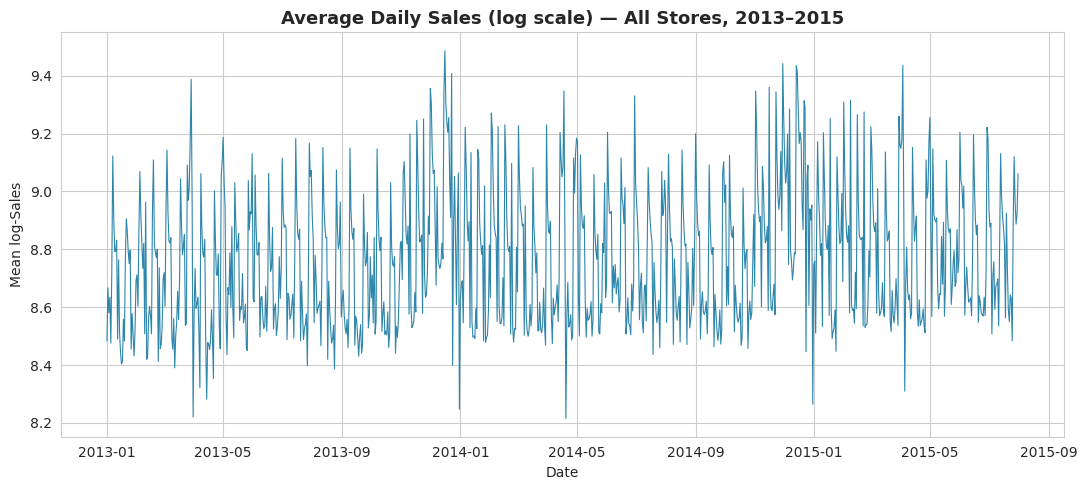

In [2]:
daily_avg = df.groupby('Date')['Sales'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(daily_avg['Date'], daily_avg['Sales'], color='#2E86AB', linewidth=0.8)
ax.set_title('Average Daily Sales (log scale) — All Stores, 2013–2015', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Mean log-Sales')
plt.tight_layout()
plt.show()

**Note:**  Daily sales stay in a pretty narrow range (about 8.0–9.5), but the same pattern repeats every year, with a clear spike at the end of each year — this matches the December peak we found earlier.

## 3. Line Graph — Monthly Average Sales Trend (Smoothed)

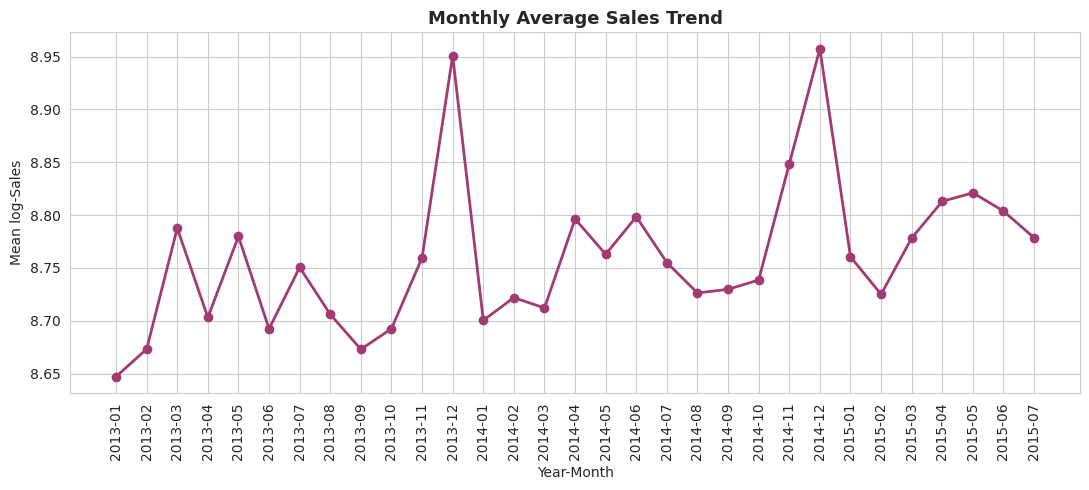

In [3]:
monthly_avg = df.groupby('YearMonth')['Sales'].mean().reset_index()

fig, ax = plt.subplots()
ax.plot(monthly_avg['YearMonth'], monthly_avg['Sales'], marker='o', color='#A23B72', linewidth=2)
ax.set_title('Monthly Average Sales Trend', fontsize=13, fontweight='bold')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Mean log-Sales')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

**Note:** Looking at monthly averages (instead of daily) removes the noise and makes two things easy to see: the sales spike every December, and a slow, steady rise in sales over the three years.

## 4. Bar Chart — Average Sales by Day of Week

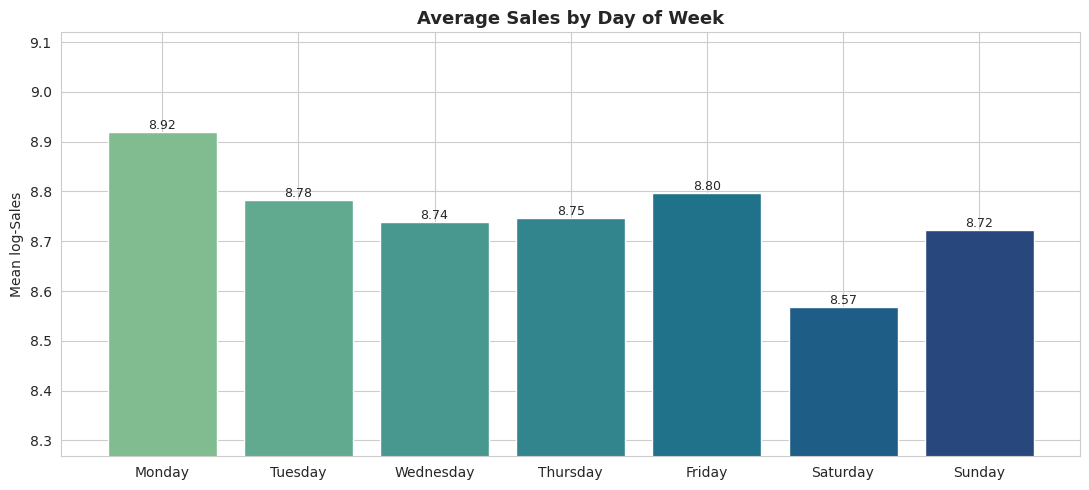

In [4]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('DayName')['Sales'].mean().reindex(dow_order)

fig, ax = plt.subplots()
bars = ax.bar(dow_avg.index, dow_avg.values, color=sns.color_palette('crest', 7))
ax.set_title('Average Sales by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean log-Sales')
ax.set_ylim(dow_avg.min() - 0.3, dow_avg.max() + 0.2)
for bar in bars:
    ax.annotate(f'{bar.get_height():.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

**Note:** Monday is always the strongest sales day, and Saturday the weakest. This might not mean less demand on Saturdays
 —
a pattern worth cross-checking against store opening-hours data, since reduced Saturday hours
(rather than reduced demand) may be the underlying driver.

## 5. Bar Chart — Average Sales by Month (Seasonality)

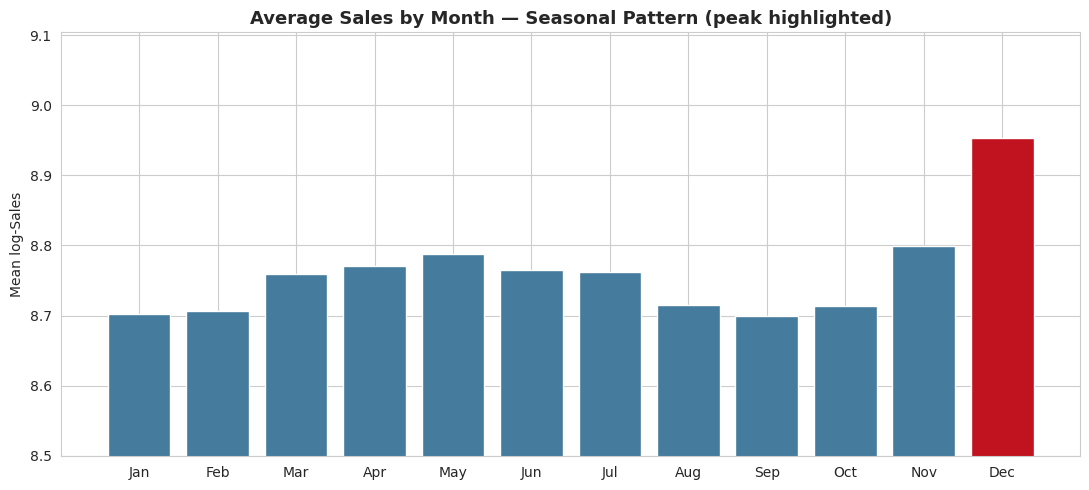

In [5]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_avg = df.groupby('MonthName')['Sales'].mean().reindex(month_order)

fig, ax = plt.subplots()
colors = ['#C1121F' if m == month_avg.idxmax() else '#457B9D' for m in month_avg.index]
ax.bar(month_avg.index, month_avg.values, color=colors)
ax.set_title('Average Sales by Month — Seasonal Pattern (peak highlighted)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean log-Sales')
ax.set_ylim(month_avg.min() - 0.2, month_avg.max() + 0.15)
plt.tight_layout()
plt.show()

**Note:** December stands out sharply as the seasonal peak (highlighted in red), confirming
the holiday-shopping effect. Spring months (April–June) form a smaller secondary bump.

## 6. Bar Chart — Promotion Effect on Sales

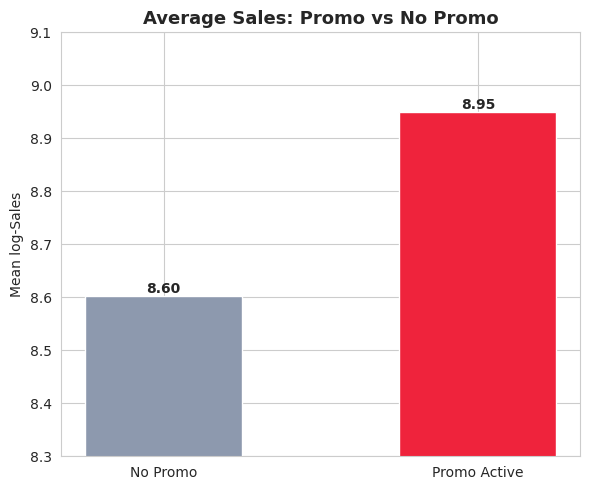

In [6]:
promo_avg = df.groupby('Promo')['Sales'].mean()
promo_avg.index = ['No Promo', 'Promo Active']

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(promo_avg.index, promo_avg.values, color=['#8D99AE', '#EF233C'], width=0.5)
ax.set_title('Average Sales: Promo vs No Promo', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean log-Sales')
ax.set_ylim(8.3, 9.1)
for bar in bars:
    ax.annotate(f'{bar.get_height():.2f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

**Note:** The chart clearly shows higher sales on promo days than non-promo days (8.95 vs. 8.60) — matching what we found earlier. Promotions are the clearest, most obvious sales driver in the whole dataset.



## 7. Bar Chart — Average Sales by Store Type and Assortment

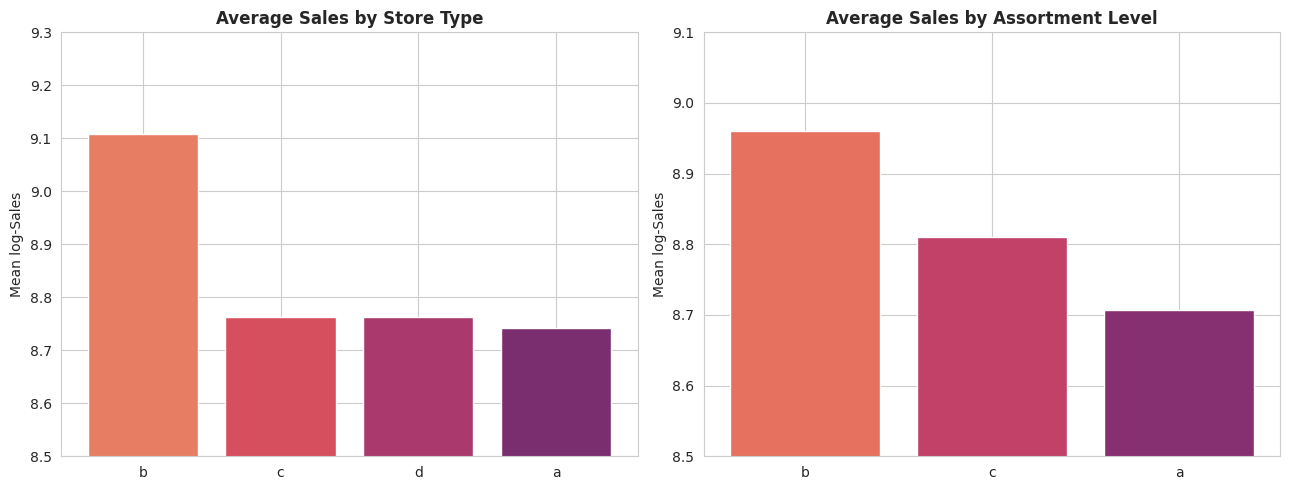

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

st_avg = df.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)
axes[0].bar(st_avg.index, st_avg.values, color=sns.color_palette('flare', 4))
axes[0].set_title('Average Sales by Store Type', fontweight='bold')
axes[0].set_ylabel('Mean log-Sales')
axes[0].set_ylim(8.5, 9.3)

as_avg = df.groupby('Assortment')['Sales'].mean().sort_values(ascending=False)
axes[1].bar(as_avg.index, as_avg.values, color=sns.color_palette('flare', 3))
axes[1].set_title('Average Sales by Assortment Level', fontweight='bold')
axes[1].set_ylabel('Mean log-Sales')
axes[1].set_ylim(8.5, 9.1)

plt.tight_layout()
plt.show()

**Note:** Store type `b` and assortment level `b` (extended product range) both stand out
as the highest-performing categories — consistent with the ANOVA result in the analysis notebook,
though both represent a small share of total stores.

## 8. Scatter Plot — Sales vs Competition Distance

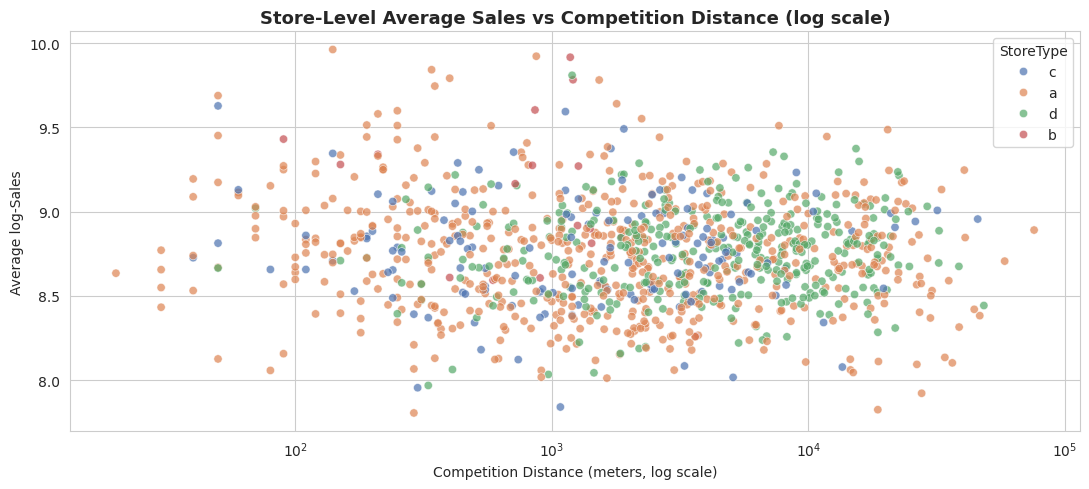

In [8]:
store_level = df.groupby('Store').agg(AvgSales=('Sales', 'mean'),
                                        CompetitionDistance=('CompetitionDistance', 'first'),
                                        StoreType=('StoreType', 'first')).reset_index()

fig, ax = plt.subplots()
sns.scatterplot(data=store_level, x='CompetitionDistance', y='AvgSales', hue='StoreType',
                 palette='deep', alpha=0.7, ax=ax)
ax.set_xscale('log')
ax.set_title('Store-Level Average Sales vs Competition Distance (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('Competition Distance (meters, log scale)')
ax.set_ylabel('Average log-Sales')
plt.tight_layout()
plt.show()

**Note:** This chart shows one point per store (not per day), since competition distance doesn't change over time. The points are scattered with no clear pattern — matching the weak correlation (-0.03) found earlier. Being close to a competitor doesn't seem to meaningfully help or hurt a store's sales.

## 9. Scatter Plot — Daily Sales Spread by Day of Week, Colored by Promo

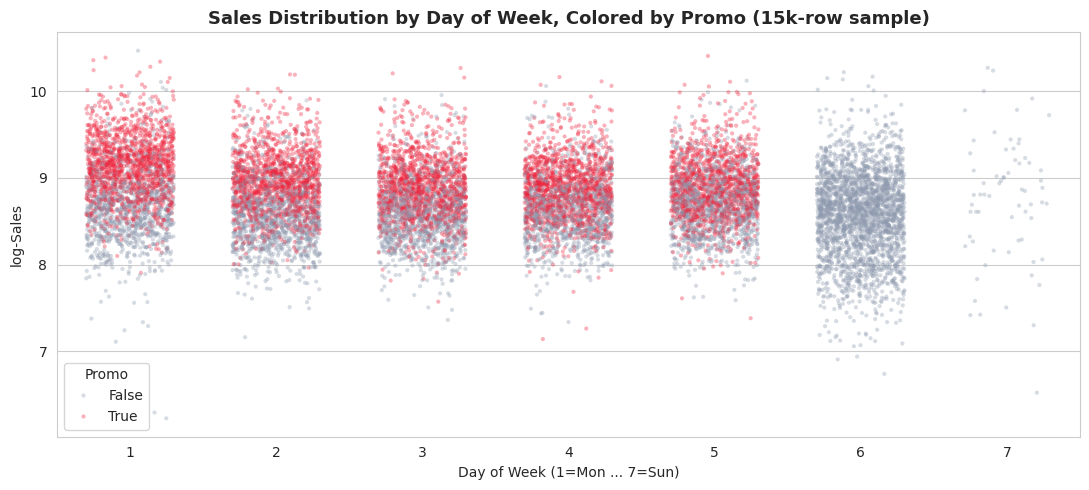

In [9]:
sample = df.sample(n=15000, random_state=42)
fig, ax = plt.subplots()
sns.stripplot(data=sample, x='DayOfWeek', y='Sales', hue='Promo', alpha=0.35, jitter=0.3,
              palette={True: '#EF233C', False: '#8D99AE'}, ax=ax, size=3)
ax.set_title('Sales Distribution by Day of Week, Colored by Promo (15k-row sample)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week (1=Mon ... 7=Sun)')
ax.set_ylabel('log-Sales')
plt.tight_layout()
plt.show()

**Note:** Sampled to 15,000 rows for a readable scatter (full 844k points would overplot
heavily). The red (promo) points visibly sit higher than gray (no-promo) points across every
day of the week, showing the promo effect holds consistently regardless of weekday.

## 10. Interactive Dashboard — Sales Trend Explorer (Plotly)

In [10]:
daily_by_type = df.groupby(['Date', 'StoreType'])['Sales'].mean().reset_index()

fig = px.line(daily_by_type, x='Date', y='Sales', color='StoreType',
              title='Interactive: Daily Average Sales by Store Type (zoom, pan, toggle legend)',
              labels={'Sales': 'Mean log-Sales', 'Date': 'Date'})
fig.update_xaxes(rangeslider_visible=True,
                  rangeselector=dict(buttons=[
                      dict(count=1, label='1m', step='month', stepmode='backward'),
                      dict(count=6, label='6m', step='month', stepmode='backward'),
                      dict(count=1, label='YTD', step='year', stepmode='todate'),
                      dict(step='all', label='All')]))
fig.update_layout(height=520, hovermode='x unified', template='plotly_white')
fig.show()

**Note:** This chart is interactive — use the slider or the 1m/6m/YTD/All buttons to zoom into any time period, click a store type in the legend to show/hide it, and hover over the line for exact values. No coding needed to explore the trends.

## 11. Interactive Dashboard — Seasonal Heatmap

In [11]:
heatmap_data = df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()
pivot = heatmap_data.pivot(index='Year', columns='Month', values='Sales')

fig = px.imshow(pivot, text_auto='.2f', color_continuous_scale='RdYlBu_r', aspect='auto',
                 labels=dict(x='Month', y='Year', color='Mean log-Sales'),
                 title='Interactive: Sales Seasonality Heatmap (Year x Month)')
fig.update_layout(height=350, template='plotly_white')
fig.update_xaxes(tickmode='array', tickvals=list(range(1, 13)),
                  ticktext=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
fig.show()

**Note:** Hover over any cell for the exact value. The heatmap makes the December peak
(darkest red column) and the relatively cooler mid-year months immediately obvious across all
three years at a glance — a compact alternative to the line-chart view above.

## 12. Interactive Dashboard — Multi-Panel Summary

In [12]:
fig = make_subplots(rows=1, cols=3,
                     subplot_titles=('Avg Sales by DayOfWeek', 'Avg Sales by StoreType', 'Promo Effect'),
                     specs=[[{'type': 'bar'}, {'type': 'bar'}, {'type': 'bar'}]])

dow_avg2 = df.groupby('DayOfWeek')['Sales'].mean()
fig.add_trace(go.Bar(x=dow_avg2.index.astype(str), y=dow_avg2.values, marker_color='#2E86AB',
                      name='DayOfWeek'), row=1, col=1)

st_avg2 = df.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)
fig.add_trace(go.Bar(x=st_avg2.index, y=st_avg2.values, marker_color='#A23B72',
                      name='StoreType'), row=1, col=2)

promo_avg2 = df.groupby('Promo')['Sales'].mean()
fig.add_trace(go.Bar(x=['No Promo', 'Promo'], y=promo_avg2.values, marker_color='#EF233C',
                      name='Promo'), row=1, col=3)

fig.update_layout(height=420, showlegend=False, template='plotly_white',
                   title_text='Interactive Summary Dashboard — Hover Any Bar for Exact Value')
fig.show()

**Note:** This dashboard puts the main sales drivers side by side for easy comparison. Hover over any bar to see the exact value. It could easily be turned into a live, filterable Dash app later if stakeholders need an always-on dashboard outside this notebook.

## 13. Summary

This notebook delivered the visualization requirements for Milestone 2:

- **Line graphs** — daily and monthly sales trends, confirming seasonality and long-term drift.
- **Bar charts** — day-of-week, monthly, promo, store-type, and assortment comparisons.
- **Scatter plots** — sales vs. competition distance, and sales spread by day/promo.
- **Interactive Plotly dashboards** — a zoomable trend explorer, a seasonal heatmap, and a
  multi-panel summary dashboard, all directly explorable in this notebook.

Together with the statistical findings in `02_statistical_analysis.ipynb`, these visuals confirm
that **Promo**, **day-of-week**, **month/seasonality**, and **store type** are the dataset's
strongest, most visually and statistically consistent sales drivers.